In [1]:
import pandas as pd

df = pd.read_csv("../data/HeatWise_Delhi_Samples.csv")

df.head()

,system:index,LST,NDVI,.geo
0,0,42.372516,0.434379,"{""type"":""Point"",""coordinates"":[77.215504018138..."
1,1,49.490543,0.379716,"{""type"":""Point"",""coordinates"":[77.223425848790..."
2,2,47.875529,0.083461,"{""type"":""Point"",""coordinates"":[77.091981419680..."
3,3,50.312577,0.320068,"{""type"":""Point"",""coordinates"":[76.981069217819..."
4,4,42.114456,0.484339,"{""type"":""Point"",""coordinates"":[77.222018218794..."


In [2]:
print(df.columns)

Index(['system:index', 'LST', 'NDVI', '.geo'], dtype='object')


In [3]:
print(df.columns)

Index(['system:index', 'LST', 'NDVI', '.geo'], dtype='object')


In [4]:
correlation = df['LST'].corr(df['NDVI'])

print("Correlation between LST and NDVI:", correlation)

Correlation between LST and NDVI: -0.447655917630744


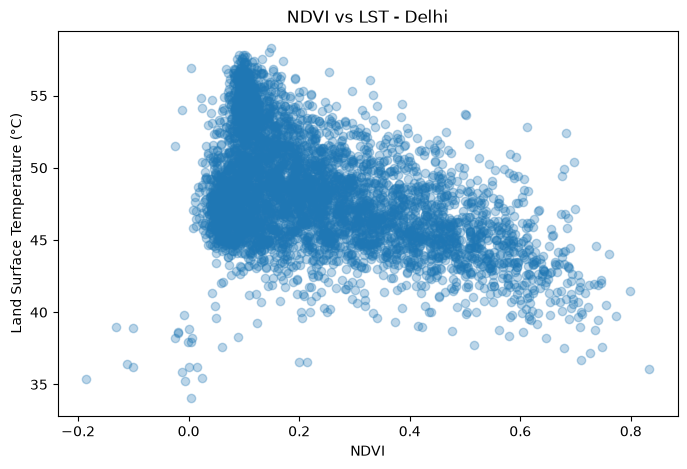

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df['NDVI'], df['LST'], alpha=0.3)

plt.xlabel("NDVI")
plt.ylabel("Land Surface Temperature (°C)")
plt.title("NDVI vs LST - Delhi")

plt.show()

In [6]:
correlation = df['LST'].corr(df['NDVI'])
print(correlation)

-0.447655917630744


In [7]:
print(df.columns)

Index(['system:index', 'LST', 'NDVI', '.geo'], dtype='object')


In [8]:
df = pd.read_csv("../data/HeatWise_Delhi_Samples_v2.csv")
print(df.columns)

Index(['system:index', 'LST', 'NDBI', 'NDVI', '.geo'], dtype='object')


In [9]:
print(df.columns)

Index(['system:index', 'LST', 'NDBI', 'NDVI', '.geo'], dtype='object')


In [10]:
print("NDVI vs LST:", df['LST'].corr(df['NDVI']))
print("NDBI vs LST:", df['LST'].corr(df['NDBI']))

NDVI vs LST: -0.447655917630744
NDBI vs LST: 0.6595634619585823


In [11]:
corr_matrix = df[['LST', 'NDVI', 'NDBI']].corr()

print(corr_matrix)

           LST      NDVI      NDBI
LST   1.000000 -0.447656  0.659563
NDVI -0.447656  1.000000 -0.832078
NDBI  0.659563 -0.832078  1.000000


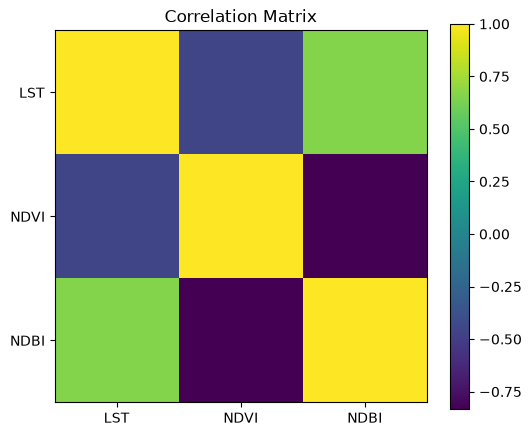

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")

plt.show()

In [13]:
from sklearn.model_selection import train_test_split

X = df[['NDVI', 'NDBI']]
y = df['LST']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4000, 2)
(1000, 2)


In [14]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [15]:
from sklearn.metrics import r2_score, mean_absolute_error

predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print("R² Score:", r2)
print("MAE:", mae)

R² Score: 0.5386657474806267
MAE: 2.0401032407993993


In [16]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

print(importance.sort_values('Importance', ascending=False))

  Feature  Importance
1    NDBI    0.682683
0    NDVI    0.317317


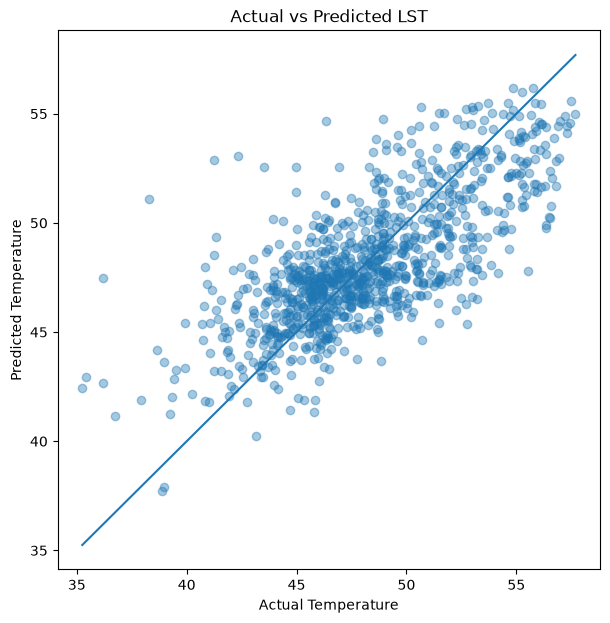

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, predictions, alpha=0.4)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted LST")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

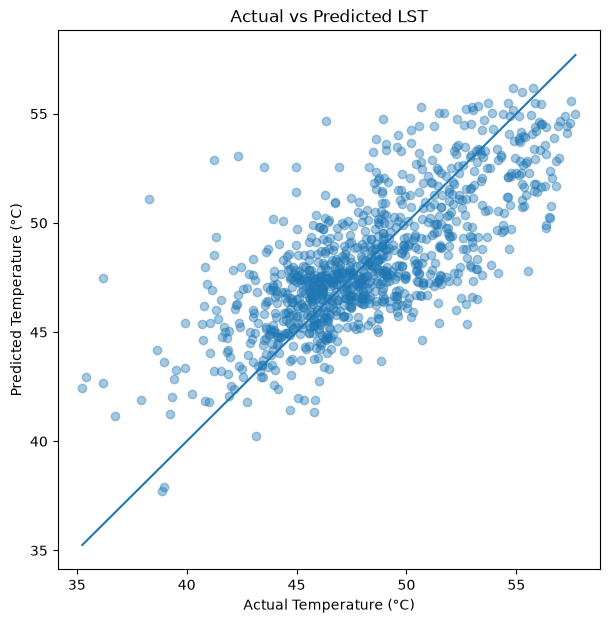

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, predictions, alpha=0.4)

plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Actual vs Predicted LST")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.savefig("../outputs/actual_vs_predicted.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

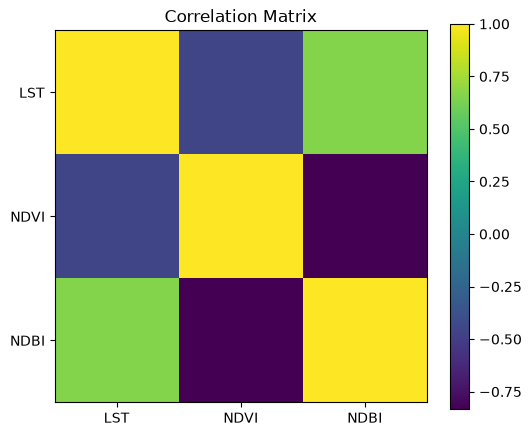

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Matrix")

plt.savefig(
    "../outputs/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
results = {
    "Metric": [
        "NDVI-LST Correlation",
        "R2 Score",
        "MAE (°C)"
    ],
    "Value": [
        -0.4477,
        0.5387,
        2.0401
    ]
}

import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Metric,Value
0,NDVI-LST Correlation,-0.4477
1,R2 Score,0.5387
2,MAE (°C),2.0401


In [21]:
results_df.to_csv(
    "../outputs/model_results.csv",
    index=False
)

print("Saved successfully")

Saved successfully
